# DS-A1 | Data Provenance and Measurement Audit

**Worked submission draft using the Iris dataset**

This notebook is designed to run top-to-bottom. It audits provenance, schema, ranges, missingness, duplicates, anomalies, and leakage risk, and records claim boundaries.

In [1]:
from pathlib import Path
import hashlib, json, platform, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SEED = 20260928
np.random.seed(SEED)

ROOT = Path.cwd()
DATA = ROOT / "data" / "iris_frozen.csv"
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
print("Python:", sys.version)
print("Platform:", platform.platform())
print("Seed:", SEED)
print("Data path:", DATA.resolve())

Python: 3.13.5 (main, Jul 15 2026, 20:25:40) [GCC 14.2.0]
Platform: Linux-6.18.44-x86_64-with-glibc2.41
Seed: 20260928
Data path: /mnt/data/DS_A1_Iris_Submission/data/iris_frozen.csv


## 1. Testable question and boundaries

**Stakeholder:** a teaching/research team demonstrating measurement-aware exploratory data science.

**Population of interest:** iris flowers belonging to the three species represented in this classic dataset (setosa, versicolor, virginica), under measurement procedures comparable to those used in the dataset.

**Sample:** 150 measured flowers in the frozen local copy.

**Unit of analysis:** one flower.

**Target:** species label.

**Testable question:** *Within this dataset, how well do petal measurements separate the three recorded iris species, and what data-quality limitations constrain that conclusion?*

**Estimand:** the difference in mean petal length between species groups in this observed sample. This is descriptive, not causal and not automatically generalizable to all iris populations.

## 2. Provenance and version freeze

Upstream source: UCI Machine Learning Repository, Iris dataset, DOI 10.24432/C56C76. The UCI page lists a CC BY 4.0 license.

For this coursework package, `data/iris_frozen.csv` is the frozen copy. Its SHA-256 is computed below so the exact bytes can be verified later.

In [2]:
raw = DATA.read_bytes()
sha256 = hashlib.sha256(raw).hexdigest()
print("SHA-256:", sha256)
assert sha256 == "7e4e13e60d330d83ae5309b440eb5ececb4b779e925cc621d8f347b1e14eeca3"

df = pd.read_csv(DATA)
print("shape:", df.shape)
df.head()

SHA-256: 7e4e13e60d330d83ae5309b440eb5ececb4b779e925cc621d8f347b1e14eeca3
shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Data-generating process / provenance lineage

Real iris flower → physical sepal/petal measurements (cm) + species assignment → historical dataset compilation → UCI repository copy → local frozen CSV → pandas audit and descriptive analysis.

Potential error can enter at measurement, labeling, transcription, repository transformation, or later preprocessing steps.

In [3]:
# Schema audit
expected_cols = [
    "sepal length (cm)", "sepal width (cm)",
    "petal length (cm)", "petal width (cm)", "target"
]
print(df.dtypes)
assert list(df.columns) == expected_cols
assert len(df) == 150
assert set(df["target"]) == {"setosa", "versicolor", "virginica"}
print("Schema checks passed.")

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                object
dtype: object
Schema checks passed.


In [4]:
# Missingness audit
missing = df.isna().sum().to_frame("missing_count")
missing["missing_pct"] = missing["missing_count"] / len(df) * 100
missing

,missing_count,missing_pct
sepal length (cm),0,0.0
sepal width (cm),0,0.0
petal length (cm),0,0.0
petal width (cm),0,0.0
target,0,0.0


In [5]:
# Duplicate audit
dup_mask = df.duplicated(keep=False)
print("Exact duplicate rows:", df.duplicated().sum())
df.loc[dup_mask].sort_values(list(df.columns)).reset_index()

Exact duplicate rows: 1


,index,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,101,5.8,2.7,5.1,1.9,virginica
1,142,5.8,2.7,5.1,1.9,virginica


In [6]:
# Range and plausibility audit
num_cols = [c for c in df.columns if c != "target"]
summary = df[num_cols].agg(["min", "max", "mean", "std"]).T
summary

# Basic physical plausibility for positive centimeter measurements
assert (df[num_cols] > 0).all().all()
print("All numeric measurements are positive.")

All numeric measurements are positive.


In [7]:
# IQR anomaly flags (flags, not automatic errors)
flags=[]
for c in num_cols:
    q1, q3 = df[c].quantile([0.25,0.75])
    iqr=q3-q1
    lo, hi=q1-1.5*iqr, q3+1.5*iqr
    idx=df.index[(df[c]<lo)|(df[c]>hi)].tolist()
    flags.append({"variable":c,"lower":lo,"upper":hi,"flagged_n":len(idx),"rows":idx})
anom = pd.DataFrame(flags)
anom

,variable,lower,upper,flagged_n,rows
0,sepal length (cm),3.15,8.35,0,[]
1,sepal width (cm),2.05,4.05,4,"[15, 32, 33, 60]"
2,petal length (cm),-3.65,10.35,0,[]
3,petal width (cm),-1.95,4.05,0,[]


In [8]:
# Class balance and simple descriptive estimand
class_counts = df['target'].value_counts().sort_index()
means = df.groupby('target')['petal length (cm)'].agg(['count','mean','std'])
print(class_counts)
means

target
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,count,mean,std
target,,,
setosa,50,1.462,0.173664
versicolor,50,4.260,0.469911
virginica,50,5.552,0.551895


In [9]:
# Pairwise differences in mean petal length (sample descriptive estimand)
mean_map = means['mean'].to_dict()
pairs=[]
labels=sorted(mean_map)
for i,a in enumerate(labels):
    for b in labels[i+1:]:
        pairs.append({"group_a":a,"group_b":b,"mean_difference_cm":mean_map[b]-mean_map[a]})
pd.DataFrame(pairs)

,group_a,group_b,mean_difference_cm
0,setosa,versicolor,2.798
1,setosa,virginica,4.090
2,versicolor,virginica,1.292


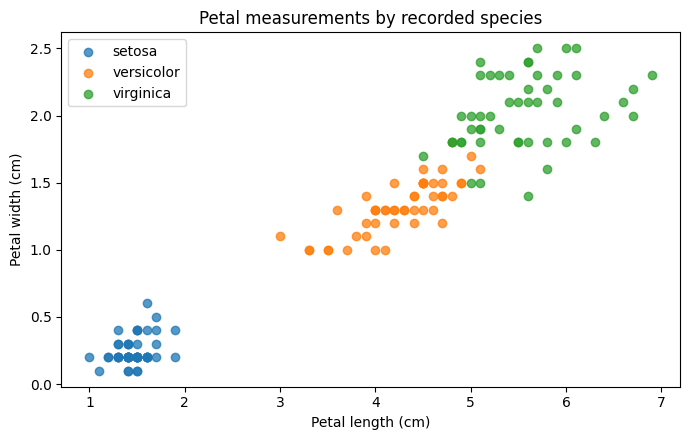

In [10]:
# Visual audit: petal length by species
fig, ax = plt.subplots(figsize=(7,4.5))
for label, g in df.groupby('target'):
    ax.scatter(g['petal length (cm)'], g['petal width (cm)'], label=label, alpha=.75)
ax.set_xlabel('Petal length (cm)')
ax.set_ylabel('Petal width (cm)')
ax.set_title('Petal measurements by recorded species')
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS/'petal_scatter.png', dpi=180)
plt.show()

## 3. Leakage audit

There is no train/test model in this assignment, but leakage still matters when defining a future predictive task. The species label (`target`) must never be used as an input feature. Any feature engineered directly from the label would also be prohibited.

If a later model is built, splitting and preprocessing must be frozen before examining test performance.

In [11]:
# Explicit leakage assertion for a hypothetical predictor
features = [c for c in df.columns if c != 'target']
target = 'target'
assert target not in features
print("Predictor columns:", features)
print("Leakage assertion passed: target is excluded from predictors.")

Predictor columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Leakage assertion passed: target is excluded from predictors.


## 4. Bias / measurement counterexample

**Counterexample:** suppose measurements came mostly from flowers grown in a narrow location or under a narrow range of environmental conditions. The observed separation in petal size could still be real for this sample but need not represent the same separation in other geographic regions, cultivars, measurement teams, or ecological conditions.

Another concern is historical sampling: the dataset is small and contains exactly 50 observations per species, which is convenient for analysis but is not evidence that the natural population contains equal proportions of these species.

## 5. Prohibited claim / claim boundary

**Prohibited claim:** “Petal size causes an iris flower to become a particular species.”

The measurements are attributes of already-existing flowers and species labels; this observational dataset does not identify a causal intervention.

Also prohibited without additional evidence: “These 150 flowers are representative of all iris flowers worldwide.”

## 6. Findings and limits

The frozen dataset has 150 rows, 4 numeric measurements, and 3 species labels. The audit finds no missing values in the frozen copy and identifies one exact duplicated row. Numeric values are positive, while IQR flags should be treated as prompts for review rather than proof of data error. Petal measurements show strong sample-level separation, especially for setosa, but this is a descriptive finding for this dataset.

The principal limitation is external validity: the historical sample and its collection process are not documented richly enough to justify broad population claims. The duplicated row also means that row independence cannot simply be assumed.

In [12]:
# Export machine-readable audit results
audit = {
    "n_rows": int(len(df)),
    "n_columns": int(df.shape[1]),
    "sha256": sha256,
    "missing_total": int(df.isna().sum().sum()),
    "exact_duplicate_rows": int(df.duplicated().sum()),
    "class_counts": {k:int(v) for k,v in class_counts.items()},
    "seed": SEED,
}
(RESULTS/'audit_summary.json').write_text(json.dumps(audit, indent=2), encoding='utf-8')
print(json.dumps(audit, indent=2))

{
  "n_rows": 150,
  "n_columns": 5,
  "sha256": "7e4e13e60d330d83ae5309b440eb5ececb4b779e925cc621d8f347b1e14eeca3",
  "missing_total": 0,
  "exact_duplicate_rows": 1,
  "class_counts": {
    "setosa": 50,
    "versicolor": 50,
    "virginica": 50
  },
  "seed": 20260928
}


## 7. AI-use and independent-verification log

AI was used to help structure the audit, draft code, and improve wording. AI-generated suggestions were independently checked by running the notebook assertions, verifying the frozen-file SHA-256, inspecting the duplicate rows, and checking the upstream UCI source/license.

Before submission, the student should add any rejected AI suggestions and describe any manual checks they personally performed. Do not claim a check you did not actually perform.